<font size="6">Лабораторная работа № 2. Анализ русскоязычного текста при помощи библиотек на языке Python</font>

---

### КЕЙС: Анализ русскоязычного текста при помощи библиотек на языке Python

---



**Цель прохождения кейса:**
Приобретение компетенций в области синтаксического, семантического, лексического и морфологического анализа текста на русском языке.

**Задачи для достижения цели:**
1.   Изучение бибилотек NLTK, Spacy, Natasha и PyMorphy.
2.   Изучение основ синтаксического анализа.
3.   Изучение основ лексического анализа.
4.   Изучение основ морфологического анализа.
5.   Изучение основ семантического анализа.
6.   Выполнение итогового задания по всем видам анализа текста.


---

# **Предварительная подготовка**

До начала работы необходимо загрузить в Colab файл с корпусом текстов для дальнейшей обработки. Для этого файл необходимо загрузить в сессионное хранилище Colab, как показано на скриншотах:

*Шаг 1:*
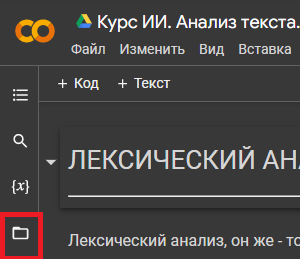

*Шаг 2:*
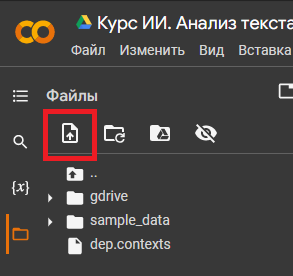

*Шаг 3:*
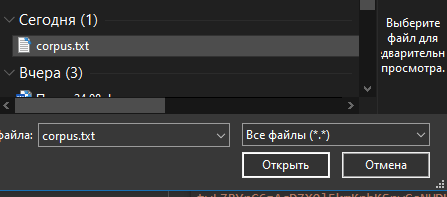

---

# **Изучение основ текстового анализа**


---
# *ЛЕКСИЧЕСКИЙ АНАЛИЗ (ТОКЕНИЗАЦИЯ)*
---

Лексический анализ, он же - токенизация, представляет собой процесс разбиения текста на более мелкие единицы, называемые **токенами**. В качестве токенов могут выступать абзацы, предложения, словосочетания слова, сочетания символов и символы, как наименьшая единица, в частности.

Токенизация является неотъемлимой частью NLP, так как нейронные сети способны обрабатывать текст исключительно в виде токенов. Запустив токенизацию на текстовом корпусе, можно получить словарь, где пары ключ-значение формируются под конкретную обучаемую модель. в таком случае значениями будут являться вложения слов, полученные такими методами как skip-gram или one-hot encoding, а ключами - токены.

**Лексический анализ (токенизация)** **- NLTK**

В рамках данного раздела для токенизации будет использована библиотека NLTK, позволяющая легко и быстро обрабатывать текстовые данные.
Для установки библиотеки необходимо выполнить команду:

In [ ]:
#!/usr/bin/python3
# coding: utf8

!pip install nltk

Следующим шагом станет установка компонентов пакета. Так как все компоненты занимают слишком много на диске и являются избыточными, следует указать параметр 'punkt' для загрузки только тех компонентов, которые отвечают за токенизацию.

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Далее следует произвести импорт модулей для токенизации по словам - word_tokenize и по предложениям - sent_tokenize.

In [ ]:
from nltk.tokenize import word_tokenize, sent_tokenize

После импорта нужных модулей, проверим корректность работы установленных компонентов на примере простого предложения. Важно! Библиотека NLTK является мультиязычной и для работы с русским языком требует указания параметра 'russian' в качестве языка для токенизатора:

In [ ]:
text = "Я - к.т.н, т.е. проучился долгое время. Имею образование."
print(sent_tokenize(text, language="russian"))
print(word_tokenize(text, language="russian"))

['Я - к.т.н, т.е. проучился долгое время.', 'Имею образование.']
['Я', '-', 'к.т.н', ',', 'т.е.', 'проучился', 'долгое', 'время', '.', 'Имею', 'образование', '.']


В результате должен быть получен результат:

['Я - к.т.н, т.е. проучился долгое время.', 'Имею образование.'] - для разделения по предложениям

['Я', '-', 'к.т.н', ',', 'т.е.', 'проучился', 'долгое', 'время', '.', 'Имею', 'образование', '.'] - для разделения по словам

---


**Лексический анализ (токенизация) - SPACY**

Библиотека NLTK - это не единственный инструмент токенизации. По аналогии с прошлым инструментов в качестве первого шага выполняется установка SPACY и вспомогательных бибилиотек.

In [ ]:
!pip install pip setuptools wheel  # установка библиотеки процессов разработки пакетов
!pip install spacy  # установка Spacy
!python -m spacy download ru_core_news_sm  # загрузка русскоязычной модели для анализа

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Далее необходимо загрузить русскоязычный пакет библиотеки:

In [ ]:
from spacy.lang.ru import Russian

Последующий вид кода для токенизации несколько отличается от NLTK. Самый простой и быстрый вариант реализации приведен ниже. Для начала происходит инициализация русскоязычного пакета, а затем различные анализы текста путем использования команды nlp().

In [ ]:
nlp = Russian()
doc = nlp(text)

Последним шагом является использование полученного парсера к тексту:

In [ ]:
print([token.text for token in doc])

['Я', '-', 'к.т.н', ',', 'т.е.', 'проучился', 'долгое', 'время', '.', 'Имею', 'образование', '.']


Результат работы Spacy для разделения по словам должен быть аналогичен NLTK.


---



**Лексический анализ (токенизация) - RAZDEL**

Последнее рассматриваемое решение - инструмент Razdel, предоставляемый русскоязычной библиотекой Natasha. На 2022 год данная библиотека является одной из наиболее эффективных. В большинстве решаемых задач она демонстрирует точность превышающую существующие мультиязычные решения. Для русского языка использование данного инструмента является предпочитительным.

Первым шагом, как и в примерах выше, является установка Razdel и импорт компонентов для уровней слов и предложений.

In [ ]:
!pip install razdel

In [ ]:
from razdel import tokenize, sentenize

За импортом следует непосредственно токенизация на слова и на предложения:

In [ ]:
print(list(tokenize(text)))
print(list(sentenize(text)))

[Substring(0, 1, 'Я'), Substring(2, 3, '-'), Substring(4, 5, 'к'), Substring(5, 6, '.'), Substring(6, 7, 'т'), Substring(7, 8, '.'), Substring(8, 9, 'н'), Substring(9, 10, ','), Substring(11, 12, 'т'), Substring(12, 13, '.'), Substring(13, 14, 'е'), Substring(14, 15, '.'), Substring(16, 25, 'проучился'), Substring(26, 32, 'долгое'), Substring(33, 38, 'время'), Substring(38, 39, '.'), Substring(40, 44, 'Имею'), Substring(45, 56, 'образование'), Substring(56, 57, '.')]
[Substring(0, 39, 'Я - к.т.н, т.е. проучился долгое время.'), Substring(40, 57, 'Имею образование.')]


**Контрольный пример**


---



Можно отметить, что результат работы Razdel хоть и является отличным от NLTK и SPACY, является более корректным с точки зрения русского языка. В качестве закрепления материала необходимо осуществить токенизацию следующих предложений:


In [ ]:
token_words = 'Кружка-термос на 0.5л (50/64 см³, 516;...)'

token_sents = '''
... - "Так в чем же дело?" - "Не ра-ду-ют".
... И т. д. и т. п. В общем, вся газета
... '''


In [ ]:
print('NLTK words')
print(sent_tokenize(token_words, language="russian"))
print('\nNLTK sents')
print(word_tokenize(token_sents, language="russian"))

print('\nSpacy words')
doc = nlp(token_words)
print([token.text for token in doc])

print('\nRAZDEL words')
print(list(tokenize(token_words)))
print('\nRAZDEL sents')
print(list(sentenize(token_sents)))

NLTK words
['Кружка-термос на 0.5л (50/64 см³, 516;...)']

NLTK sents
['...', '-', '``', 'Так', 'в', 'чем', 'же', 'дело', '?', "''", '-', '``', 'Не', 'ра-ду-ют', "''", '.', '...', 'И', 'т.', 'д.', 'и', 'т.', 'п.', 'В', 'общем', ',', 'вся', 'газета', '...']

Spacy words
['Кружка', '-', 'термос', 'на', '0.5л', '(', '50/64', 'см³', ',', '516', ';', '...', ')']

RAZDEL words
[Substring(0, 13, 'Кружка-термос'), Substring(14, 16, 'на'), Substring(17, 20, '0.5'), Substring(20, 21, 'л'), Substring(22, 23, '('), Substring(23, 28, '50/64'), Substring(29, 32, 'см³'), Substring(32, 33, ','), Substring(34, 37, '516'), Substring(37, 38, ';'), Substring(38, 41, '...'), Substring(41, 42, ')')]

RAZDEL sents
[Substring(1, 27, '... - "Так в чем же дело?"'), Substring(28, 48, '- "Не ра-ду-ют".\n...'), Substring(49, 64, 'И т. д. и т. п.'), Substring(65, 88, 'В общем, вся газета\n...')]


# СИНТАКСИЧЕСКИЙ АНАЛИЗ
---

Синтаксический анализ представляет собой процесс определения принадлежности некоторой последовательности лексем языку, порождаемому грамматикой.

Инструменты для реализации этого вида анализа аналогичны предназначенным для лексического, т.е. nltk, spacy, natasha и многие другие. Однако, как показывают результаты, для русского языка наиболее простыми и удобными являются лишь два из них - Spacy и Natasha. Еще одним инструментом является PyMorphy2.

**Синтаксический анализ - Natasha (связан с сегментацией)**

Так как ранее один из модулей библиотеки Natasha - Razdel - был установлен самостоятельно, необходимо произвести установку полного набора компонентов библиотеки:

In [ ]:
!pip install natasha

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 92.2 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=434c035d18a8daf092f9983bc8268c245105394032678c4e5a5e4fadee060c53
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


Слеудующим шагом необходимо загрузить и инициализировать модули, предназначенные для анализа текста. Подробнее о каждом из них:

1.   Segmenter - осуществляет разбиение на токены и предложения, фукнционируя на основе Razdel, представленном в разделе о лексическом анализе.
2.   NewsEmbedding - векторные представления слов новостного корпуса - используются для построение анализаторов морфологии и синтаксиса.
3.   NewsMorphTagger и NewsSyntaxParser - непосредственно анализаторы морфологии и синтаксиса.
4.   Doc - объект библиотеки Natasha, осуществляющий анализ текста.


In [ ]:
from natasha import (
    Segmenter,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc)

segmenter = Segmenter()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)

In [ ]:
with open('corpus_rus.txt', 'r', encoding='utf-8') as c:
  c = c.read()
  text = c.split('\n')[0]

Файл `corpus_rus.txt` показан ниже:

In [ ]:
text

'\ufeffПрошло семь лет. Наташа в 1813 г. выходит за Пьера. Старый граф Ростов умирает. Николай выходит в отставку, принимает наследство — долгов оказывается вдвое больше, чем имения. Он вместе с матерью и Соней поселяется в Москве, в скромной квартире. Встретив княжну Марью, он пытается быть с ней сдержанным и сухим (ему неприятна мысль о женитьбе на богатой невесте), но между ними происходит объяснение, и осенью 1814 г. Ростов женится на княжне Болконской. Они переезжают в Лысые Горы; Николай умело ведёт хозяйство и вскоре расплачивается с долгами. Соня живёт в его доме; «она, как кошка, прижилась не к людям, а к дому». В декабре 1820 г. Наташа с детьми гостит у брата. Ждут приезда Пьера из Петербурга. Приезжает Пьер, привозит всем подарки. В кабинете между Пьером, Денисовым (он тоже гостит у Ростовых) и Николаем происходит разговор, Пьер — член тайного общества; он говорит о дурном правительстве и необходимости перемен. Николай не соглашается с Пьером и говорит, что не может принять 

In [ ]:
natasha_doc = Doc(text)

In [ ]:
natasha_doc.segment(segmenter)
print(natasha_doc.tokens[:8])
print(natasha_doc.sents[:8])

[DocToken(stop=7, text='\ufeffПрошло'), DocToken(start=8, stop=12, text='семь'), DocToken(start=13, stop=16, text='лет'), DocToken(start=16, stop=17, text='.'), DocToken(start=18, stop=24, text='Наташа'), DocToken(start=25, stop=26, text='в'), DocToken(start=27, stop=31, text='1813'), DocToken(start=32, stop=33, text='г')]
[DocSent(stop=17, text='\ufeffПрошло семь лет.', tokens=[...]), DocSent(start=18, stop=52, text='Наташа в 1813 г. выходит за Пьера.', tokens=[...]), DocSent(start=53, stop=80, text='Старый граф Ростов умирает.', tokens=[...]), DocSent(start=81, stop=176, text='Николай выходит в отставку, принимает наследство ..., tokens=[...]), DocSent(start=177, stop=246, text='Он вместе с матерью и Соней поселяется в Москве, ..., tokens=[...]), DocSent(start=247, stop=455, text='Встретив княжну Марью, он пытается быть с ней сде..., tokens=[...]), DocSent(start=456, stop=484, text='Они переезжают в Лысые Горы;', tokens=[...]), DocSent(start=485, stop=549, text='Николай умело ведёт х

In [ ]:
natasha_doc.parse_syntax(syntax_parser)
print(natasha_doc.tokens[:20])
for i in range(5):
  natasha_doc.sents[i].syntax.print()

[DocToken(stop=7, text='\ufeffПрошло', id='1_1', head_id='1_3', rel='punct'), DocToken(start=8, stop=12, text='семь', id='1_2', head_id='1_3', rel='nummod:gov'), DocToken(start=13, stop=16, text='лет', id='1_3', head_id='1_0', rel='root'), DocToken(start=16, stop=17, text='.', id='1_4', head_id='1_3', rel='punct'), DocToken(start=18, stop=24, text='Наташа', id='2_1', head_id='2_6', rel='nsubj'), DocToken(start=25, stop=26, text='в', id='2_2', head_id='2_4', rel='case'), DocToken(start=27, stop=31, text='1813', id='2_3', head_id='2_4', rel='amod'), DocToken(start=32, stop=33, text='г', id='2_4', head_id='2_6', rel='obl'), DocToken(start=33, stop=34, text='.', id='2_5', head_id='2_6', rel='punct'), DocToken(start=35, stop=42, text='выходит', id='2_6', head_id='2_0', rel='root'), DocToken(start=43, stop=45, text='за', id='2_7', head_id='2_8', rel='case'), DocToken(start=46, stop=51, text='Пьера', id='2_8', head_id='2_6', rel='obl'), DocToken(start=51, stop=52, text='.', id='2_9', head_id=



---



**Синтаксический анализ** **- PyMorphy**

Одним из самых популярных решений в области морфологического анализа текстов на русском языке является инструкмент PyMorpy2. Для работы по данному разделу необходимо установить библиотеку для обработки естественного языка PyMorphy и загрузить ее русскоязычную модель.

In [ ]:
!pip install pymorphy2

Непосредственно для для морфологического анализа необходимо использовать один из классов PyMorphy - MorphAnalyzer. Русский язык у данной библиотеки установлен по умолчанию, поэтому нет необходимости в подгрузке дополнительных пакетов.

In [ ]:
import pymorphy2
morph = pymorphy2.MorphAnalyzer()

Важно помнить, что экземпляры класса MorphAnalyzer занимают много места в ОЗУ, поэтому следует писать код таким образом, чтобы экзампляр этого класса создавался заранее для последующей работы с ним.

Для разрабора отдельных слов необходимо использовать метод MorphAnalyzer.parse. Ниже приведен пример его работы со словом "стекло".

In [ ]:
morph.parse('стекло')

[Parse(word='стекло', tag=OpencorporaTag('NOUN,inan,neut sing,nomn'), normal_form='стекло', score=0.690476, methods_stack=((DictionaryAnalyzer(), 'стекло', 157, 0),)),
 Parse(word='стекло', tag=OpencorporaTag('NOUN,inan,neut sing,accs'), normal_form='стекло', score=0.285714, methods_stack=((DictionaryAnalyzer(), 'стекло', 157, 3),)),
 Parse(word='стекло', tag=OpencorporaTag('VERB,perf,intr neut,sing,past,indc'), normal_form='стечь', score=0.023809, methods_stack=((DictionaryAnalyzer(), 'стекло', 1015, 3),))]

В выводе видно, что MorphAnalyzer возвращает один или несколько объектов типа Parse с информацией о возможных разрборах слова.
В приведенном примере слово “стекло” может быть разобрано и как глагол (“что-то жидкое стекло по стене”), и как существительное (“это самое прочное стекло из производимых на заводе”).
Очевидно, что, руководствуясь лишь информацией о написании слова, понять, какой разбор правильный, нельзя, поэтому метод возвращает один и более вариантов.

Каждый из выполненных MorphAnalyzer-ом разборов имеет набор граммем, описывающих слово или Тэг. Например, тэг 'NOUN,inan,neut sing,nomn' означает, что слово - существительное (NOUN) неодушевлённое (inan), среднего рода (neut), единственного числа (sing), именительного падежа (nomn).

In [ ]:
morph.parse('стекло')[0].tag

OpencorporaTag('NOUN,inan,neut sing,nomn')

Помимо подробного мофологического анализа, PyMorphy имеет еще одну полезную функцию - возможность склонения слов. Для этого необходимо определить, в какой форме слово стоит в настоящий момент и какая у него лексема. Другими словами, нужно сперва разобрать слово и выбрать из предложенных вариантов разбора правильный.

Для примера разберем слово “стекло” и возьмем первый вариант разбора, чтобы преобразовать его в родительный падеж.

In [ ]:
morph.parse('стекло')[0].inflect({'gent'})

Parse(word='стекла', tag=OpencorporaTag('NOUN,inan,neut sing,gent'), normal_form='стекло', score=1.0, methods_stack=((DictionaryAnalyzer(), 'стекла', 157, 1),))

 ***

# МОРФОЛОГИЧЕСКИЙ АНАЛИЗ
---

**Морфологический анализ** - Natasha (связан с сегментацией)

In [ ]:
natasha_doc.tag_morph(morph_tagger)  # ПЕРЕНЕСТИ В МОРФО
print(natasha_doc.tokens[:5])
for i in range(5):
  natasha_doc.sents[i].morph.print()

[DocToken(stop=7, text='\ufeffПрошло', id='1_1', head_id='1_3', rel='punct', pos='PUNCT'), DocToken(start=8, stop=12, text='семь', id='1_2', head_id='1_3', rel='nummod:gov', pos='NUM', feats=<Acc>), DocToken(start=13, stop=16, text='лет', id='1_3', head_id='1_0', rel='root', pos='NOUN', feats=<Inan,Gen,Masc,Plur>), DocToken(start=16, stop=17, text='.', id='1_4', head_id='1_3', rel='punct', pos='PUNCT'), DocToken(start=18, stop=24, text='Наташа', id='2_1', head_id='2_6', rel='nsubj', pos='PROPN', feats=<Anim,Nom,Fem,Sing>)]
             ﻿Прошло PUNCT
                семь NUM|Case=Acc
                 лет NOUN|Animacy=Inan|Case=Gen|Gender=Masc|Number=Plur
                   . PUNCT
              Наташа PROPN|Animacy=Anim|Case=Nom|Gender=Fem|Number=Sing
                   в ADP
                1813 ADJ
                   г NOUN|Animacy=Inan|Case=Loc|Gender=Masc|Number=Sing
                   . PUNCT
             выходит VERB|Aspect=Imp|Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin

Обратите внимание! Лексический и морфологический анализ при помощи PyMorphy доступен только после сегментации текста!

***

# Латентно-семантический анализ (LSA) - Sklearn



TF-IDF (Term Frequency-Inverse Document Frequency) — это статистическая мера, используемая для оценки важности слова в контексте документа. Она состоит из двух частей:

TF (Частота термина) - насколько часто слово встречается в документе

IDF (Обратная частота документа) - насколько редко слово встречается во всех документах

In [ ]:
import pandas as pd

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Создаём и обучаем векторизатор
tfidf = TfidfVectorizer()
text = ['Помимо подробного мофологического анализа, PyMorphy имеет еще одну полезную функцию - возможность склонения слов. Для этого необходимо определить, в какой форме слово стоит в настоящий момент и какая у него лексема. Другими словами, нужно сперва разобрать слово и выбрать из предложенных вариантов разбора правильный.',
'Для примера разберем слово “стекло” и возьмем первый вариант разбора, чтобы преобразовать его в родительный падеж.']
tfidf.fit(text)

Словарь: {'помимо': 28, 'подробного': 26, 'мофологического': 17, 'анализа': 1, 'pymorphy': 0, 'имеет': 12, 'еще': 10, 'одну': 22, 'полезную': 27, 'функцию': 45, 'возможность': 4, 'склонения': 37, 'слов': 38, 'для': 7, 'этого': 47, 'необходимо': 20, 'определить': 23, 'какой': 14, 'форме': 44, 'слово': 40, 'стоит': 43, 'настоящий': 18, 'момент': 16, 'какая': 13, 'него': 19, 'лексема': 15, 'другими': 8, 'словами': 39, 'нужно': 21, 'сперва': 41, 'разобрать': 35, 'выбрать': 6, 'из': 11, 'предложенных': 30, 'вариантов': 3, 'разбора': 34, 'правильный': 29, 'примера': 32, 'разберем': 33, 'стекло': 42, 'возьмем': 5, 'первый': 25, 'вариант': 2, 'чтобы': 46, 'преобразовать': 31, 'его': 9, 'родительный': 36, 'падеж': 24}


Создаётся объект, который преобразует текст в числовые векторы.

Векторизатор изучает все уникальные слова в тексте и строит словарь.

In [ ]:
print("Словарь:", tfidf.vocabulary_)

Словарь: {'помимо': 28, 'подробного': 26, 'мофологического': 17, 'анализа': 1, 'pymorphy': 0, 'имеет': 12, 'еще': 10, 'одну': 22, 'полезную': 27, 'функцию': 45, 'возможность': 4, 'склонения': 37, 'слов': 38, 'для': 7, 'этого': 47, 'необходимо': 20, 'определить': 23, 'какой': 14, 'форме': 44, 'слово': 40, 'стоит': 43, 'настоящий': 18, 'момент': 16, 'какая': 13, 'него': 19, 'лексема': 15, 'другими': 8, 'словами': 39, 'нужно': 21, 'сперва': 41, 'разобрать': 35, 'выбрать': 6, 'из': 11, 'предложенных': 30, 'вариантов': 3, 'разбора': 34, 'правильный': 29, 'примера': 32, 'разберем': 33, 'стекло': 42, 'возьмем': 5, 'первый': 25, 'вариант': 2, 'чтобы': 46, 'преобразовать': 31, 'его': 9, 'родительный': 36, 'падеж': 24}


In [ ]:
# Преобразуем тексты в матрицу TF-IDF
X = tfidf.transform(text)
text[1]

'Для примера разберем слово “стекло” и возьмем первый вариант разбора, чтобы преобразовать его в родительный падеж.'

Текст преобразуется в матрицу, где:

Строки = документы (в данном случае 1 строка)

Столбцы = уникальные слова из словаря

Значения = TF-IDF веса слов

In [ ]:
print("Размер матрицы:", X.shape)
print(f"Количество документов: {X.shape[0]}, количество уникальных слов: {X.shape[1]}")
print(f"Уникальных слов в словаре: {len(tfidf.vocabulary_)}")

Размер матрицы: (2, 48)
Количество документов: 2, количество уникальных слов: 48
Уникальных слов в словаре: 48


In [ ]:
print([X[1, tfidf.vocabulary_['падеж']]])

[np.float64(0.28263102299414045)]


Здесь происходит:

tfidf.vocabulary_['падеж'] - получаем индекс слова "падеж" в словаре

X[1, индекс] - берём значение для второго документа (индекс 1) и слова "падеж"

Получаем TF-IDF вес = 0.2826

In [ ]:
# Получаем вес слова "падеж" во втором документе
word = 'падеж'
if word in tfidf.vocabulary_:
    word_index = tfidf.vocabulary_[word]
    tfidf_value = X[1, word_index]
    print(f"TF-IDF вес слова '{word}' во втором документе: {tfidf_value:.4f}")

    # Для сравнения: вес того же слова в первом документе
    tfidf_value_first = X[0, word_index]
    print(f"TF-IDF вес слова '{word}' в первом документе: {tfidf_value_first:.4f}")
else:
    print(f"Слово '{word}' не найдено в словаре")

# Показать все слова с их индексами
print("\nПервые 10 слов словаря:")
for i, (word, idx) in enumerate(list(tfidf.vocabulary_.items())[:10]):
    print(f"{i+1}. '{word}' -> индекс {idx}")

TF-IDF вес слова 'падеж' во втором документе: 0.2826
TF-IDF вес слова 'падеж' в первом документе: 0.0000

Первые 10 слов словаря:
1. 'помимо' -> индекс 28
2. 'подробного' -> индекс 26
3. 'мофологического' -> индекс 17
4. 'анализа' -> индекс 1
5. 'pymorphy' -> индекс 0
6. 'имеет' -> индекс 12
7. 'еще' -> индекс 10
8. 'одну' -> индекс 22
9. 'полезную' -> индекс 27
10. 'функцию' -> индекс 45


## Задание: Комплексный анализ русскоязычного текста и определение его стиля

В рамках данной лабораторной работы необходимо разработать программу для комплексного лингвистического анализа текста на русском языке с использованием библиотек NLTK, SpaCy, Natasha и pymorphy2. Итогом работы должен стать вывод о преобладающем стиле текста (художественный, публицистический или научный) на основе вычисленных характеристик.

### Датасет
Создайте 3 файла, содержащий три разных фрагмента текста, каждый из которых принадлежит к одному из трех стилей: **художественный**, **публицистический** или **научный**.

### Этапы выполнения задания

1.  **Загрузка и предварительная обработка данных.**
    *   Загрузите файлы.
    *   Разделите содержимое на три отдельных текста для последующего анализа.

2.  **Лексический анализ (Токенизация).**
    *   Используя библиотеку `NLTK`, выполните токенизацию на слова для каждого из трех текстов.
    *   Используя библиотеку `SpaCy`, также выполните токенизацию на слова для каждого текста.
    *   Используя библиотеку `razdel` (из пакета Natasha), выполните самую качественную токенизацию на слова и предложения.
    *   Сравните результаты токенизации разными инструментами. Для каких аспектов текста (аббревиатуры, знаки препинания, числа) какой инструмент справляется лучше?

3.  **Синтаксический анализ.**
    *   Используя библиотеку `Natasha` (компоненты `Segmenter`, `NewsSyntaxParser`), выполните синтаксический анализ для первого предложения каждого из трех текстов.
    *   Визуализируйте (выведите на экран с помощью `syntax.print()`) полученные деревья зависимостей. Опишите, чем они отличаются (например, наличие причастных/деепричастных оборотов, сложных союзов и т.д.).

4.  **Морфологический анализ.**
    *   Для результатов токенизации, полученных с помощью `razdel`, выполните морфологический разбор с использованием `pymorphy2`.
    *   Для каждого из трех текстов определите и выведите:
        *   5 самых частотных частей речи (в процентах от общего числа слов в тексте). Для каких стилей характерно большее количество глаголов? Для каких — прилагательных или существительных?
        *   Количество глаголов в прошедшем, настоящем и будущем времени.

5.  **Семантический анализ (LSA) и решение основной задачи.**
    *   Используя `TfidfVectorizer` из библиотеки `sklearn`, преобразуйте все три текста в матрицы "документ-термин" (примените лемматизацию с помощью `pymorphy2` для улучшения качества).
    *   Вычислите попарное косинусное сходство между текстами.
    *   **Задача:** Основываясь на всех полученных ранее характеристиках (частотность частей речи, синтаксическая структура, семантическая близость), сделайте обоснованный вывод о том, какой из трех текстов является художественным, какой публицистическим, а какой научным.
        *   *Подсказки для анализа:*
        *   **Художественный текст:** Много глаголов, прилагательных, разнообразие времен глаголов, сложные синтаксические конструкции (причастные обороты), метафоры.
        *   **Публицистический текст:** Много существительных и прилагательных, клишированные фразы, призывы, риторические вопросы, более простой синтаксис.
        *   **Научный текст:** Много существительных (терминов), родительный падеж, сложные предложения с союзами, безличные конструкции.

### Критерии оценивания

Оценка производится по правильности определения стиля для каждого из трех текстов.

* **Правильное определение стиля для 1 текста — 25 баллов.**
* **Правильное определение стиля для 2 текстов — 30 баллов.**
* **Правильное определение стиля для 3 текстов — 35 баллов.**

Баллы выставляются только при условии успешной защиты лабораторной работы. На защите студент должен:
*   Продемонстрировать работоспособность кода.
*   Объяснить, какие лингвистические признаки и почему он использовал для классификации.
*   Ответить на теоретические вопросы по лексическому, морфологическому, синтаксическому и семантическому анализу.

### Задания для повышение оценки
1. **Кастомизация и векторизация - 6 баллов**

Используя регулярные выражения (библиотека re), напишите свою функцию для токенизации на слова, которая сможет корректно обрабатывать:
* Аббревиатуры с точками (т.е., к.т.н., США)
* Числа с десятичной запятой/точкой (0.5л, 50/64)
* Дефис в словах (ра-ду-ют, кружка-термос)

Сравните точность вашего токенизатора с razdel на фрагменте текста.

2. **Эксперименты с векторизацией - 4 баллов**

Помимо TfidfVectorizer, используйте CountVectorizer для создания матрицы "документ-термин". Сравните результаты косинусного сходства для текстов, полученные с помощью обоих методов. Объясните различия.

3. **Обучение простого классификатора и Визуализация "облака слов" - 5 баллов**

Разбейте каждый из трех текстов на отдельные предложения. Присвойте каждому предложению метку класса (0 — художественный, 1 — публицистический, 2 — научный). Используя векторизацию на уровне предложений, обучите классификатор (например, логистическую регрессию) для предсказания стиля отдельного предложения. Оцените точность модели.

Для каждого из трех текстов постройте "облако слов" (word cloud) с помощью библиотеки wordcloud. Исключите из облака стоп-слова. Проанализируйте, какие слова доминируют в облаке для каждого стиля.